# Example-09: Frequency vs signal start shift (noise)

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

Window(8192, 'cosine_window', 1.0)
Data(1, Window(8192, 'cosine_window', 1.0))
Data(7169, Window(1024, 'cosine_window', 1.0))
Frequency(Data(7169, Window(1024, 'cosine_window', 1.0)), f_range=(0.0, 0.5))
tensor(1.171875000000e-04, dtype=torch.float64)
tensor(1.320590831966e-07, dtype=torch.float64)
tensor(1.260852658391e-09, dtype=torch.float64)


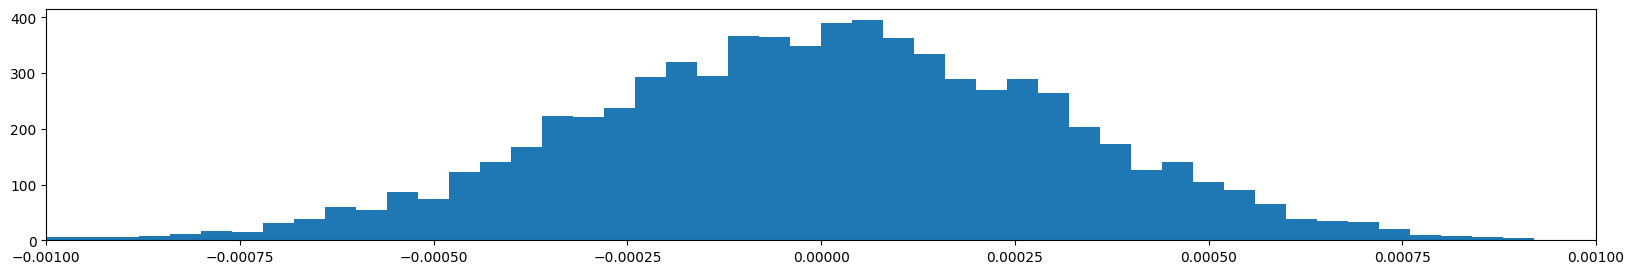

tensor(3.666917332971e-07, dtype=torch.float64)


In [3]:
# Set parameters (1 signal with length 8192)

size, length = 1, 8192

# Set window

w = Window.from_cosine(length, order=1.0, dtype=dtype, device=device)
print(w)

# Set TbT data (1 signals with two components)

t = torch.linspace(1.0, length, length, dtype=dtype, device=device)
data = torch.stack([i*torch.sin(2.0*numpy.pi*1*0.12*t) + 0.01*i*torch.sin(2.0*numpy.pi*2*0.12*t) for i in range(1, size + 1)])
d = Data.from_data(w, data)
print(d)

# Generate matrix shifted signal

data = d.make_matrix(1024, 1, d.data[0])
w = Window.from_cosine(1024, order=1.0, dtype=dtype, device=device)
d = Data.from_data(w, data)
print(d)

# Add noise to each signal

for i in range(d.size):
    d.data[i] += 0.01*torch.randn(d.length, dtype=dtype, device=device)
d.reset()

# Initialize Frequency instance

f = Frequency(d)
print(f)

# Apply window (note, window is applied to work)

d.window_remove_mean()
d.window_apply()

# Estimate frequency, see also task_parabola

f('parabola')

# Compare results

print(torch.abs(torch.mean(f.fft_frequency) - 0.12))
print(torch.abs(torch.mean(f.ffrft_frequency) - 0.12))
print(torch.abs(torch.mean(f.parabola_frequency) - 0.12))

# Plot result

plt.figure(figsize=(20, 3))
plt.hist(100*(f.frequency.cpu().numpy() - 0.12)/0.12, bins=50, range=(-1.0E-3, +1.0E-3))
plt.xlim(-1.0E-3, +1.0E-3)
plt.show()

# Spread

print(f.parabola_frequency.std().cpu())

# Clean

del w
del t, data
del d
del f
if device != torch.device('cpu'):
    torch.cuda.synchronize()
    torch.cuda.empty_cache()